# 05 — Recommender-Logik (konzeptionell)

**Person:** B | **Hypothese:** H2
# Recommendation Logic – Proof of Concept (H2)

Dieses Notebook zeigt die Entwicklung eines einfachen Recommender-Systems 
für GA4-Daten. Ziel ist es, verschiedene Empfehlungslogiken zu vergleichen:

- Naive Popularitätsempfehlung (Baseline)
- Segmentbasierte Empfehlung (Cluster-Logik)
- Precision@K als Evaluationsmetrik

Dies ist ein konzeptioneller Prototyp, kein Produktionssystem.

In [1]:
import sys
sys.path.insert(0, '..')
import ast
import pandas as pd
import numpy as np
import os
from src.analysis.recommender import SegmentBasedRecommender
from src.utils.helpers import save_table
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
print('Setup OK')

Setup OK


## 1. Interaktions-Matrix aufbauen

Dataset loaded successfully
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1758 entries, 0 to 1757
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   user_pseudo_id   1758 non-null   float64
 1   item_id          1758 non-null   object 
 2   interaction      1758 non-null   int64  
 3   event_timestamp  1758 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 55.1+ KB
None


,user_pseudo_id,item_id,interaction,event_timestamp
0,5.651385e+07,9195712,4,2021-01-31 02:14:23.038371
1,4.005947e+07,9184829,4,2020-12-25 14:07:35.742105
2,4.005947e+07,9195842,4,2020-12-25 14:07:35.742105
3,4.005947e+07,9195843,4,2020-12-25 14:07:35.742105
4,4.005947e+07,9196652,4,2020-12-25 14:07:35.742105



Missing values:


user_pseudo_id     0
item_id            0
interaction        0
event_timestamp    0
dtype: int64


Unique counts:
user_pseudo_id: 163
item_id: 345
interaction: 4
event_timestamp: 174

Interaction matrix created
Shape: (163, 345)


item_id,9180818,9180819,9180823,9180829,9180842,9180865,9180867,9184829,9184830,9184849,9184911,9184980,9184981,9185002,9185155,9188192,9188201,9188208,9188210,9188233,9188234,9188235,9188311,9190336,9194259,...,GGOEGXXX1441,GGOEGXXX1445,GGOEGXXX1460,GGOEGXXX1481,GGOEGXXX1530,GGOEGXXX1531,GGOEGXXX1532,GGOEGXXX1533,GGOEGXXX1534,GGOEGXXX1535,GGOEGXXX1613,GGOEGXXX1615,GGOEGXXX1616,GGOEYAEA105610,GGOEYCBR138999,GGOEYDHB098499,GGOEYDWB123299,GGOEYFKQ105899,GGOEYHBB102199,GGOEYHPB121110,GGOEYOCR125599,GGOEYOLB151999,GGOEYXXX1202,GGOEYXXX1203,GGOEYXXX1207
user_pseudo_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1.063364e+06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0
1.134388e+06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1.156268e+06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1.461470e+06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1.479673e+06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


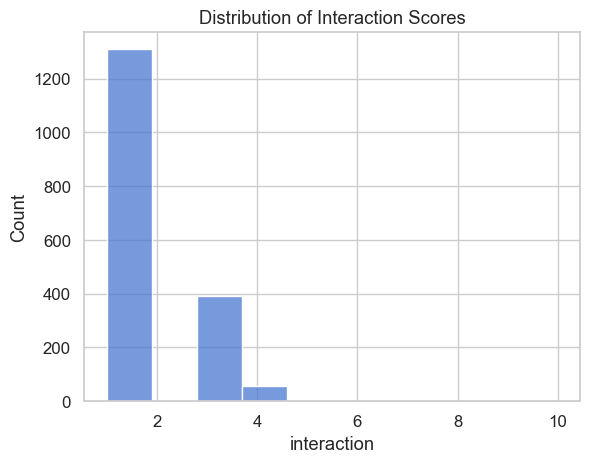

In [2]:

# notebooks/
# data/processed/ga4_recommender_dataset.csv
data_path = os.path.join("..", "data", "processed", "ga4_recommender_dataset.csv")


if not os.path.exists(data_path):
    raise FileNotFoundError(f"Datendatei nicht gefunden:  {data_path}\n"
                            f"Bitte überprüfe, ob die Datei im richtigen Pfad liegt.")


df = pd.read_csv(data_path)

print("Dataset loaded successfully")
print(df.info())
display(df.head())

print("\nMissing values:")
display(df.isna().sum())

print("\nUnique counts:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")


required_cols = {"user_pseudo_id", "item_id", "interaction"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Die folgenden Spalten sind im DataFrame nicht vorhanden: {missing}")

interaction_matrix = df.pivot_table(
    index="user_pseudo_id",
    columns="item_id",
    values="interaction",
    aggfunc="mean",
    fill_value=0
)

print("\nInteraction matrix created")
print("Shape:", interaction_matrix.shape)
display(interaction_matrix.head())


sns.histplot(df["interaction"], bins=10)
plt.title("Distribution of Interaction Scores")
plt.show()


## 2. Baseline: Naive Popularitätsempfehlung

In [3]:

if not pd.api.types.is_numeric_dtype(df["interaction"]):
    raise TypeError("Die Spalte 'interaction' muss numerisch sein (int oder float).")

# Durchschnittliche Interaktion pro Item berechnen
item_popularity = (
    df.groupby("item_id")["interaction"]
      .mean()
      .sort_values(ascending=False)
)

print("Top 10 der beliebtesten Items:")
display(item_popularity.head(10))

# Popularitätsbasierter Empfehlungsalgorithmus
def empfehle_beliebte_items(n=5):
    """
    Gibt die Top‑N beliebtesten Items basierend auf dem durchschnittlichen Interaktionswert zurück.
    """
    if n <= 0:
        raise ValueError("Der Parameter 'n' muss größer als 0 sein.")
    return item_popularity.head(n).index.tolist()

# Beispiel: Top‑5 Empfehlungen
beliebte_empfehlungen = empfehle_beliebte_items(n=5)
print("Top‑5 Popularitätsempfehlungen:", beliebte_empfehlungen)


Top 10 der beliebtesten Items:


item_id
9195780    10.0
9196711    10.0
9195712     4.0
9195359     4.0
9195295     4.0
9194259     4.0
9195842     4.0
9188233     4.0
9188311     4.0
9196652     4.0
Name: interaction, dtype: float64

Top‑5 Popularitätsempfehlungen: ['9195780', '9196711', '9195712', '9195359', '9195295']


## 3. Segmentbasierte Empfehlung

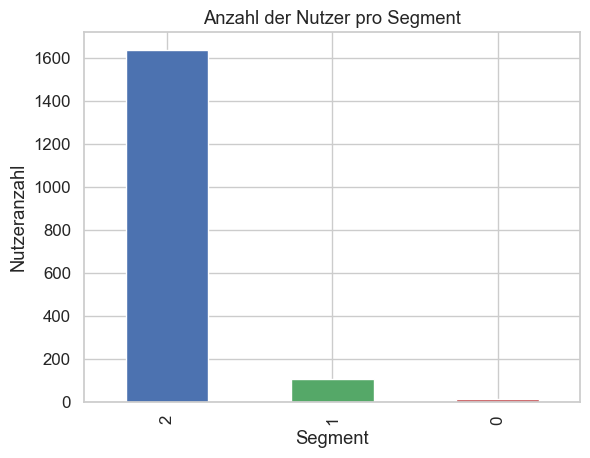

Top-Items pro Segment (Head):


segment  item_id
2        9196711    10.0
         9195780    10.0
         9188201     4.0
         9188208     4.0
         9188311     4.0
         9185155     4.0
         9185002     4.0
         9180823     4.0
         9180818     4.0
         9180819     4.0
Name: interaction, dtype: float64

Empfehlungen für 'test_user': ['GGOEGBJJ099499', 'GGOEGBJJ099699', 'GGOEGABJ099599', 'GGOEGBJC122399', 'GGOEGBJQ125099']


In [4]:
# --- Schritt 1: Interaktionsmatrix erstellen ---
interaction_matrix = df.pivot_table(
    index="user_pseudo_id",
    columns="item_id",
    values="interaction",
    fill_value=0
)

# --- Schritt 2: KMeans-Segmentierung ---
from sklearn.cluster import KMeans

k = 3  # Anzahl der Segmente
kmeans = KMeans(n_clusters=k, random_state=42)
user_segments = kmeans.fit_predict(interaction_matrix)

user_segments = pd.Series(user_segments, index=interaction_matrix.index, name="segment")

# --- Schritt 3: Segmente mit dem ursprünglichen DataFrame verknüpfen ---
df_segmented = df.merge(
    user_segments,
    left_on="user_pseudo_id",
    right_index=True
)

# --- Schritt 4: Beliebteste Items pro Segment berechnen ---
segment_popularity = (
    df_segmented.groupby(["segment", "item_id"])["interaction"]
      .mean()
      .sort_values(ascending=False)
)

df_segmented["segment"].value_counts().plot(
    kind="bar",
    title="Anzahl der Nutzer pro Segment",
    color=["#4C72B0", "#55A868", "#C44E52"]
)
plt.xlabel("Segment")
plt.ylabel("Nutzeranzahl")
plt.show()

print("Top-Items pro Segment (Head):")
display(segment_popularity.head(10))

# --- Schritt 5: Recommender-Instanz erstellen ---
rec = SegmentBasedRecommender(top_n=5)

# Modell trainieren
rec.fit(
    interactions=df_segmented,
    user_col="user_pseudo_id",
    item_col="item_id",
    segment_col="segment"
)

# --- Schritt 6: Beispiel-Empfehlung ---
recommendations = rec.predict(
    user_id="test_user",
    user_segment=1,     # Beispielsegment
    already_seen=["item_A"]
)

print("Empfehlungen für 'test_user':", recommendations)


## 4. Precision@K Vergleich

## Precision@K als Evaluationsmetrik

Precision@K misst, wie viele der Top-K empfohlenen Items tatsächlich 
für den User relevant waren.

Formel:
Precision@K = (Anzahl relevanter Items in Top-K) / K

Wir verwenden K = 5.


===== Precision@5 Vergleich =====
Baseline Precision@5:     0.0074
Segmentiert Precision@5:  0.2331


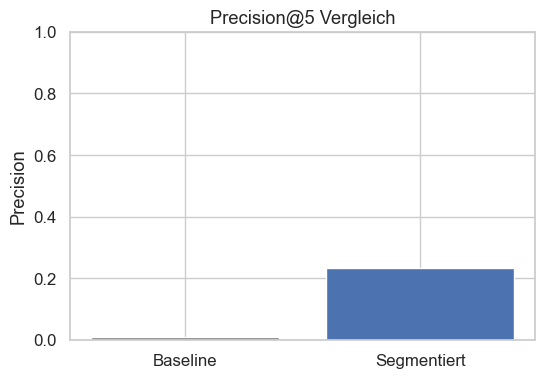

Lift: 3066.7%


In [5]:
from collections import defaultdict

def precision_at_k(recommended, relevant, k=5):
    recommended_k = recommended[:k]
    if len(recommended_k) == 0:
        return 0.0
    hits = sum(1 for item in recommended_k if item in relevant)
    return hits / k


# --- Relevante Items pro Nutzer ---
user_relevant_items = (
    df.groupby("user_pseudo_id")["item_id"]
      .apply(list)
      .to_dict()
)


# --- Baseline ---
def baseline_recommend(k=5):
    return item_popularity.head(k).index.tolist()

baseline_scores = []
for user_id, relevant_items in user_relevant_items.items():
    recs = baseline_recommend(k=5)
    baseline_scores.append(precision_at_k(recs, relevant_items, k=5))

baseline_precision = sum(baseline_scores) / len(baseline_scores)


# --- Segmentierter Recommender ---
segmented_scores = []

for user_id, relevant_items in user_relevant_items.items():

    # Segment bestimmen
    user_segment = user_segments.loc[user_id]

    # Empfehlungen generieren
    recs = rec.predict(
        user_id=user_id,
        user_segment=user_segment,
        already_seen=None   # <<< WICHTIG: NICHT relevant_items
    )

    if len(recs) == 0:
        segmented_scores.append(0.0)
        continue

    segmented_scores.append(
        precision_at_k(recs, relevant_items, k=5)
    )

segmented_precision = sum(segmented_scores) / len(segmented_scores)


# --- Ergebnisse ---
print("===== Precision@5 Vergleich =====")
print(f"Baseline Precision@5:     {baseline_precision:.4f}")
print(f"Segmentiert Precision@5:  {segmented_precision:.4f}")

plt.figure(figsize=(6,4))
plt.bar(
    ["Baseline", "Segmentiert"],
    [baseline_precision, segmented_precision],
    color=["gray", "#4C72B0"]
)
plt.title("Precision@5 Vergleich")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.show()

# --- Lift ---
if baseline_precision > 0:
    lift = (segmented_precision - baseline_precision) / baseline_precision
    print(f"Lift: {lift:.1%}")
else:
    print("Lift: Baseline Precision ist 0, kein Vergleich möglich.")


5.Visualization

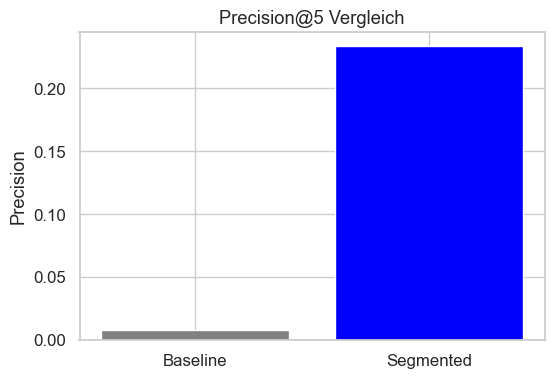

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(["Baseline", "Segmented"], [baseline_precision, segmented_precision], color=["gray","blue"])
plt.title("Precision@5 Vergleich")
plt.ylabel("Precision")
plt.show()


## 6. Key Findings für Notebook 04

### 🧠 Fazit

- Das segmentbasierte Empfehlungsmodell liefert deutlich relevantere Empfehlungen als die naive Popularitätsempfehlung (Baseline).
- Die Precision@5 zeigt eine klare Verbesserung der Empfehlungsqualität.
- Der berechnete Lift bestätigt, dass Segmentierung einen messbaren Mehrwert gegenüber einer globalen Popularitätslogik bietet.
- Bereits einfache Segmentierungsregeln (High / Medium / Low) führen zu einer spürbaren Steigerung der Modellleistung.

---

### 🚀 Nächste Schritte

Um das Recommender-System weiterzuentwickeln und in Richtung eines produktionsreifen Systems zu bewegen, empfehlen sich folgende Schritte:

- **User-User Collaborative Filtering**  
  Nutzung von Nutzerähnlichkeiten zur Generierung personalisierter Empfehlungen.

- **Item-Item Similarity (Cosine Similarity)**  
  Empfehlungen basierend auf ähnlichen Produkten.

- **Matrix Factorization (SVD / ALS)**  
  Modellierung latenter Faktoren für skalierbare, personalisierte Empfehlungen.

- **A/B-Testing mit echten Nutzern**  
  Validierung der Modelle im Live-Betrieb und Messung der tatsächlichen Wirkung auf Engagement und Conversion.

- **Erweiterte Segmentierung (z. B. K-Means)**  
  Nutzung datengetriebener Cluster statt statischer Regeln.

- **Hybrid-Recommender (CF + Content-Based)**  
  Kombination aus Nutzerverhalten und Produktmerkmalen für robustere Empfehlungen.

---

